In [1]:
import os
print(os.getcwd())

os.chdir("/home/tanasa/CHEMISTRY_GNN/data")
print(os.getcwd())

/home/tanasa/CHEMISTRY_GNN
/home/tanasa/CHEMISTRY_GNN/data


In [2]:
# https://selfies.readthedocs.io/en/latest/selfies.html

In [3]:
# SELFIES does not directly encode chemistry visually like SMILES.

# Instead, it encodes:

# atoms
# bond instructions
# branch instructions
# ring instructions

# using a grammar that guarantees valid molecules.

In [4]:
import selfies as sf

sf.encoder("c1ccccc1")     # SMILES → SELFIES: '[C][=C][C][=C][C][=C][Ring1][=Branch1]'
sf.decoder("[C][=C][C]")   # SELFIES → SMILES: 'C=CC'

'C=CC'

In [5]:
# sf.get_semantic_robust_alphabet()   # default token set

In [6]:
from rdkit import Chem
from rdkit.Chem import Draw

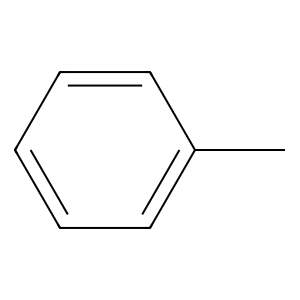

In [7]:
m = Chem.MolFromSmiles('Cc1ccccc1')
print(m)
img = Draw.MolToImage(m)
img

In [8]:
# Detect invalid SMILES

In [9]:
# Detect invalid SMILES

m1 = Chem.MolFromSmiles('CO(C)C')
print(m1 is None)

True


[12:30:07] Explicit valence for atom # 1 O, 3, is greater than permitted


In [10]:
# Detect invalid SMILES

m2 = Chem.MolFromSmiles('c1cc1')
print(m2 is None)

True


[12:30:07] Can't kekulize mol.  Unkekulized atoms: 0 1 2


In [11]:
# Kekulization

In [12]:
# before kekulization : c1ccccc1

m = Chem.MolFromSmiles('c1ccccc1')
print(m.GetBondWithIdx(0).GetBondType())

# after kekulization : C1=CC=CC=C1

Chem.Kekulize(m)
print(m.GetBondWithIdx(0).GetBondType())

AROMATIC
SINGLE


In [13]:
# ASPIRIN

In [14]:
print("ASPIRIN")

ASPIRIN


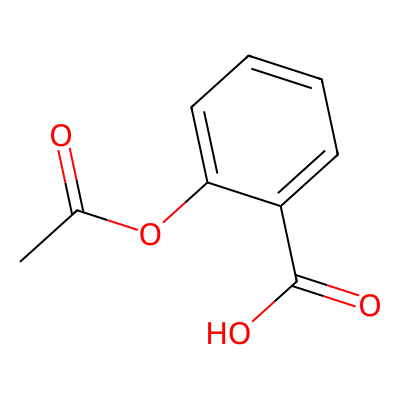

SMILES:
CC(=O)Oc1ccccc1C(=O)O

SELFIES:
[C][C][=Branch1][C][=O][O][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=Branch1][C][=O][O]

Decoded SMILES from SELFIES:
CC(=O)OC1=CC=CC=C1C(=O)O


In [15]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
import selfies as sf

# Aspirin SMILES
smiles = "CC(=O)Oc1ccccc1C(=O)O"

# Convert SMILES to RDKit molecule
mol = Chem.MolFromSmiles(smiles)

# Display molecule
display(Draw.MolToImage(mol, size=(400, 400)))

# Convert SMILES to SELFIES
selfie = sf.encoder(smiles)

print("SMILES:")
print(smiles)

print("\nSELFIES:")
print(selfie)

# Convert SELFIES back to SMILES
decoded_smiles = sf.decoder(selfie)

print("\nDecoded SMILES from SELFIES:")
print(decoded_smiles)

In [16]:
# kekule representation : CC(=O)OC1=CC=CC=C1C(=O)O
# it is equivalent to : CC(=O)Oc1ccccc1C(=O)O

In [17]:
# acetyl ester      [C][C][=Branch1][C][=O][O]
# +
# benzene ring      [C][=C][C][=C][C][=C][Ring1]
# +
# carboxylic acid   [C][=Branch1][C][=O][O]

In [18]:
# [C][C][=Branch1][C][=O][O]

In [19]:
# [C][=C][C][=C][C][=C][Ring1]

In [20]:
# [C][=Branch1][C][=O][O]

In [21]:
# [C][C][=Branch1][C][=O][O]

In [22]:
print('''

In the aspirin fragment :

      O
      ||
CH3 — C — O

The middle carbon is connected to:

left carbon (CH3)
double-bonded oxygen
single-bonded oxygen

So this carbon has THREE connections.

Without branching : 

If we tried: [C][C][O][O]

decoder would interpret: C-C-O-O

which is WRONG.

That becomes a chain: CH3-CH-O-O

instead of: CH3-C(=O)-O

Therefore we need a branch

SELFIES says: [C][C][=Branch1][C][=O][O]

Meaning: main chain: CH3 — C — O PLUS a side branch: (=O)

''')



In the aspirin fragment :

      O
      ||
CH3 — C — O

The middle carbon is connected to:

left carbon (CH3)
double-bonded oxygen
single-bonded oxygen

So this carbon has THREE connections.

Without branching : 

If we tried: [C][C][O][O]

decoder would interpret: C-C-O-O

which is WRONG.

That becomes a chain: CH3-CH-O-O

instead of: CH3-C(=O)-O

Therefore we need a branch

SELFIES says: [C][C][=Branch1][C][=O][O]

Meaning: main chain: CH3 — C — O PLUS a side branch: (=O)




In [23]:
# [C][=C][C][=C][C][=C][Ring1]

# BENZENE : Important chemistry insight : 

# REAL benzene is NOT actually:
# single-double-single-double
# Instead:
# electrons are delocalized
# But many cheminformatics systems use:
# Kekulé representation internally

# decoder sees [Ring1]

# Now decoder asks:

# Which earlier atom can current atom connect to
# while preserving valid chemistry?

# For benzene:

# atom 6 still has open valence
# atom 1 still has open valence

# Connecting: 6 → 1
# creates valid ring.

# So decoder closes ring there.

In [24]:
# Benzene in SMILES

print
# Correct benzene:
# C1=CC=CC=C1

# The two 1s mean:
# start ring here
# close ring here

# Potential SMILES confusion

# Imagine AI generates:
# C1=CC=CC=C
# Problem:
# ring never closes
# INVALID.

# Another bad example
# C1=CC=CC=C2

# Problem:
# ring starts with 1
# closes with 2

# INVALID.

<function print>

[C][=C][C][=C][C][=C][Ring1][=Branch1]
C1=CC=CC=C1


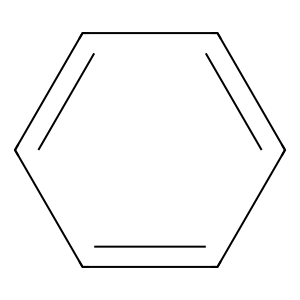

In [25]:
# Kekulé representation

# with alternating:

# single bonds
# double bonds

from rdkit import Chem
from rdkit.Chem import Draw
import selfies as sf

smiles = "c1ccccc1"

# SMILES -> SELFIES
selfie = sf.encoder(smiles)

print(selfie)

# Decode back
decoded = sf.decoder(selfie)

print(decoded)

mol = Chem.MolFromSmiles(decoded)

Draw.MolToImage(mol, size=(300,300))

In [26]:
# carboxylic acid   [C][=Branch1][C][=O][O]

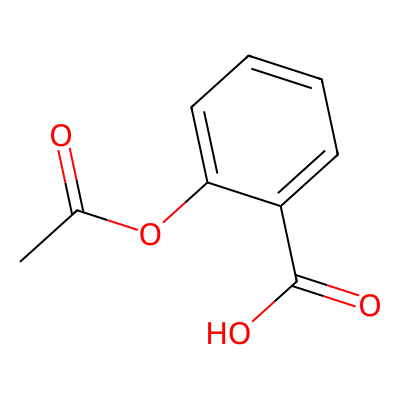

SMILES:
CC(=O)Oc1ccccc1C(=O)O

SELFIES:
[C][C][=Branch1][C][=O][O][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=Branch1][C][=O][O]

Decoded SMILES from SELFIES:
CC(=O)OC1=CC=CC=C1C(=O)O


In [27]:
# Aspirin SMILES
smiles = "CC(=O)Oc1ccccc1C(=O)O"

# Convert SMILES to RDKit molecule
mol = Chem.MolFromSmiles(smiles)

# Display molecule
display(Draw.MolToImage(mol, size=(400, 400)))

# Convert SMILES to SELFIES
selfie = sf.encoder(smiles)

print("SMILES:")
print(smiles)

print("\nSELFIES:")
print(selfie)

# Convert SELFIES back to SMILES
decoded_smiles = sf.decoder(selfie)

print("\nDecoded SMILES from SELFIES:")
print(decoded_smiles)

In [28]:
# carboxylic acid   [C][=Branch1][C][=O][O]

In [29]:
# The confusing part is:

# [C][=Branch1][C][=O][O]

# Why do we have:

# one [C] BEFORE the branch
# another [C] AFTER the branch?

# Short answer

# Because these two carbons play DIFFERENT roles.

# Token	Role
# first [C]	the MAIN carbonyl carbon in the molecule
# second [C]	helper atom inside the branch construction grammar

# SELFIES internally builds branches using graph-expansion rules.

# The branch itself needs:

# an attachment node
# branch continuation context

# So the decoder introduces another carbon token as part of branch construction semantics.

# You can think of it as:

# temporary branch expansion atom
# before applying: [=O]

In [30]:
print('''

[C][=Branch1][C][=O][O]

Meaning:

Token	Meaning
[C]	main carbonyl carbon
[=Branch1]	create double-bond branch
[C]	branch construction carbon
[=O]	double-bonded oxygen
[O]	hydroxyl oxygen

''')



[C][=Branch1][C][=O][O]

Meaning:

Token	Meaning
[C]	main carbonyl carbon
[=Branch1]	create double-bond branch
[C]	branch construction carbon
[=O]	double-bonded oxygen
[O]	hydroxyl oxygen




In [ ]:
# SELFIES : on github

In [ ]:
# https://github.com/aspuru-guzik-group/selfies

In [32]:
import selfies as sf

benzene = "c1ccccc1"

# SMILES -> SELFIES -> SMILES translation
try:
    benzene_sf = sf.encoder(benzene)      # [C][=C][C][=C][C][=C][Ring1][=Branch1]
    benzene_smi = sf.decoder(benzene_sf)  # C1=CC=CC=C1
except sf.EncoderError:
    pass  # sf.encoder error!
except sf.DecoderError:
    pass  # sf.decoder error!

len_benzene = sf.len_selfies(benzene_sf)  # 8
print(len_benzene)

symbols_benzene = list(sf.split_selfies(benzene_sf))
print(symbols_benzene)
# ['[C]', '[=C]', '[C]', '[=C]', '[C]', '[=C]', '[Ring1]', '[=Branch1]']

8
['[C]', '[=C]', '[C]', '[=C]', '[C]', '[=C]', '[Ring1]', '[=Branch1]']


In [33]:
benzene_sf

'[C][=C][C][=C][C][=C][Ring1][=Branch1]'

In [34]:
benzene_smi

'C1=CC=CC=C1'